# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Datasets

In [2]:
customers = pd.read_csv('../data/processed/customers_cleaned.csv')
geolocation = pd.read_csv('../data/processed/geolocation_cleaned.csv')
order_items = pd.read_csv('../data/processed/order_items_cleaned.csv')
order_payments = pd.read_csv('../data/processed/order_payments_cleaned.csv')
order_reviews = pd.read_csv('../data/processed/order_reviews_cleaned.csv')
orders = pd.read_csv('../data/processed/orders_cleaned.csv')
product_category = pd.read_csv('../data/processed/product_category_cleaned.csv')
products = pd.read_csv('../data/processed/products_cleaned.csv')
sellers = pd.read_csv('../data/processed/sellers_cleaned.csv')

# Statistics

## Descriptive Statistics

In [3]:
# order_items
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


> **Nota:** freight_value possui valor maximo de R$409.68 com alto desvio padrao,
> sugerindo variacao regional significativa. A ser investigado na analise de logistica.

In [4]:
# order_payments
order_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103884.000000,103884.000000,103884.000000
mean,1.092661,2.853404,154.101531
std,0.706579,2.687047,217.495943
min,1.000000,1.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.840000
max,29.000000,24.000000,13664.080000


In [5]:
# order_reviews
order_reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


## Distribution Analysis

In [6]:
# order_items - skewness and kurtosis
pd.DataFrame({
    'skewness': order_items[['price', 'freight_value']].skew(),
    'kurtosis': order_items[['price', 'freight_value']].kurt()
}).round(2)

,skewness,kurtosis
price,7.92,120.83
freight_value,5.64,59.79


In [7]:
# order_payments - skewness and kurtosis
pd.DataFrame({
    'skewness': order_payments[['payment_value', 'payment_installments']].skew(),
    'kurtosis': order_payments[['payment_value', 'payment_installments']].kurt()
}).round(2)

,skewness,kurtosis
payment_value,9.25,241.82
payment_installments,1.66,2.55


In [8]:
# order_reviews - skewness and kurtosis
pd.DataFrame({
    'skewness': order_reviews[['review_score']].skew(),
    'kurtosis': order_reviews[['review_score']].kurt()
}).round(2)

,skewness,kurtosis
review_score,-1.36,0.51


> **Nota:** todas as variaveis financeiras apresentam alto skewness positivo,
> indicando que a mediana e mais representativa que a media para esse dataset.

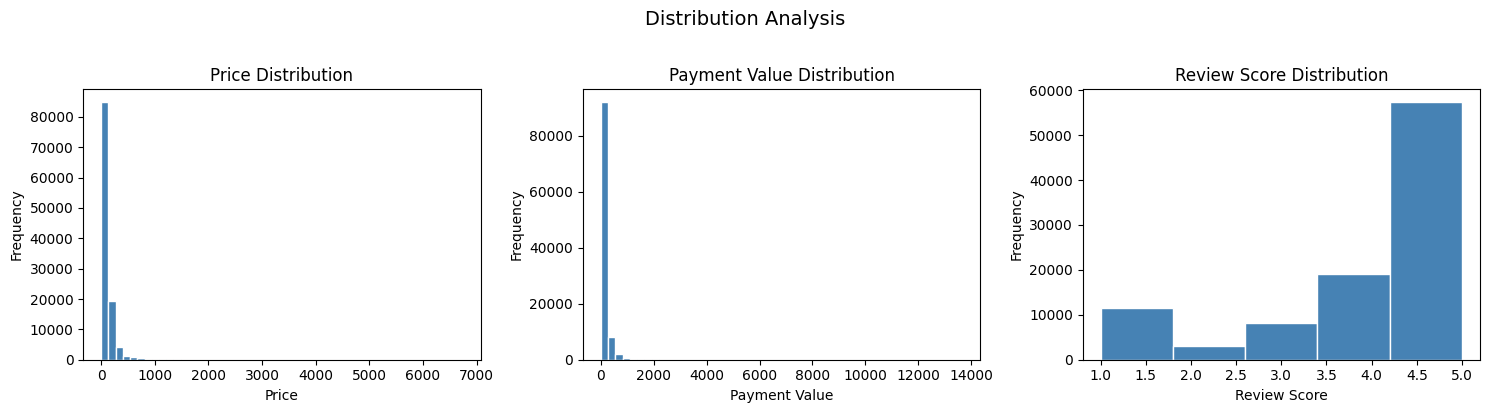

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# price
axes[0].hist(order_items['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# payment_value
axes[1].hist(order_payments['payment_value'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Payment Value Distribution')
axes[1].set_xlabel('Payment Value')
axes[1].set_ylabel('Frequency')

# review_score
axes[2].hist(order_reviews['review_score'], bins=5, color='steelblue', edgecolor='white')
axes[2].set_title('Review Score Distribution')
axes[2].set_xlabel('Review Score')
axes[2].set_ylabel('Frequency')

plt.suptitle('Distribution Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

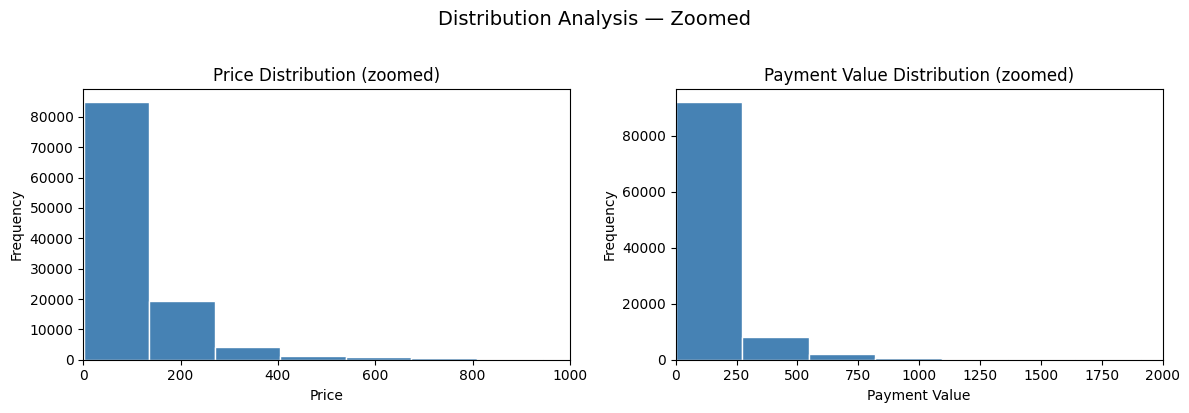

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# price — zoomed
axes[0].hist(order_items['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlim(0, 1000)
axes[0].set_title('Price Distribution (zoomed)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# payment_value — zoomed
axes[1].hist(order_payments['payment_value'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlim(0, 2000)
axes[1].set_title('Payment Value Distribution (zoomed)')
axes[1].set_xlabel('Payment Value')
axes[1].set_ylabel('Frequency')

plt.suptitle('Distribution Analysis — Zoomed', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Correlation Analysis

In [11]:
# Correlation analysis
df_corr_full = orders.merge(order_reviews[['order_id', 'review_score']], on='order_id')
df_corr_full = df_corr_full.merge(order_items[['order_id', 'price', 'freight_value']], on='order_id')
df_corr_full = df_corr_full.merge(order_payments[['order_id', 'payment_value', 'payment_installments']], on='order_id')

df_corr_full[['price', 'freight_value', 'payment_value', 'payment_installments', 'review_score']].corr().round(2)

,price,freight_value,payment_value,payment_installments,review_score
price,1.00,0.41,0.74,0.28,-0.00
freight_value,0.41,1.00,0.37,0.19,-0.04
payment_value,0.74,0.37,1.00,0.27,-0.08
payment_installments,0.28,0.19,0.27,1.00,-0.04
review_score,-0.00,-0.04,-0.08,-0.04,1.00


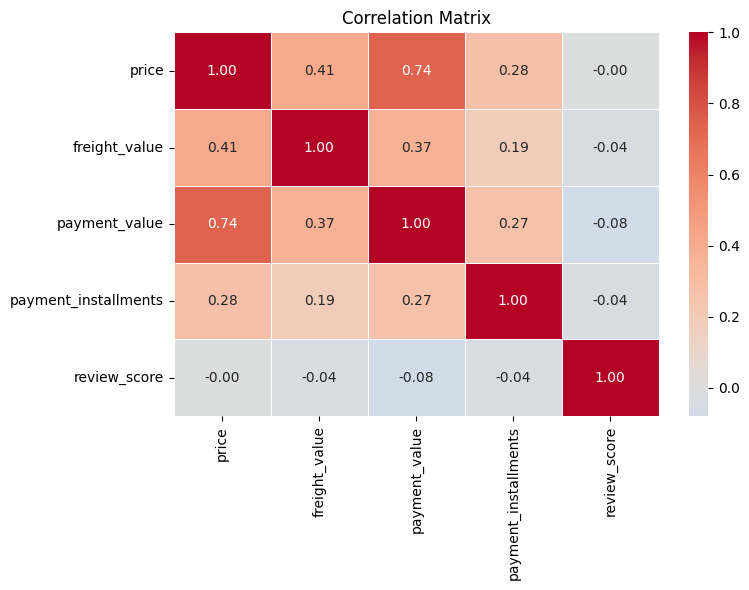

In [12]:
# Correlation heatmap
corr_matrix = df_corr_full[['price', 'freight_value', 'payment_value', 'payment_installments', 'review_score']].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

> **Nota:** nenhuma variavel financeira apresenta correlacao relevante com review_score,
> sugerindo que satisfacao do cliente e determinada por fatores operacionais como
> prazo de entrega, e nao pelo valor pago.

## Conclusions

**1. Satisfacao do cliente nao e determinada por variaveis financeiras**
Nenhuma variavel financeira (price, freight_value, payment_value) apresentou
correlacao relevante com review_score. A satisfacao esta mais relacionada a
fatores operacionais como prazo de entrega, a ser investigado em 05_satisfaction_analysis.

**2. Variaveis financeiras tem distribuicao assimetrica**
Price, freight_value e payment_value apresentam alto skewness positivo, indicando
que a mediana e mais representativa que a media para esse dataset. A maioria dos
produtos custa menos de R$75, mas outliers de alto valor distorcem a media para R$120.

**3. Comportamento de parcelamento reflete o valor do produto**
Existe correlacao positiva de 0.28 entre price e payment_installments, confirmando
que consumidores brasileiros tendem a parcelar compras de maior valor, comportamento
tipico do mercado de e-commerce nacional.